# 08: Final Model Comparison & Inference Pipeline

This notebook represents the culmination of the CSIRO Image2Biomass project.

**Objectives:**
1. Load out-of-fold (OOF) predictions from the advanced classical model (Notebook 06) and the end-to-end CNN (Notebook 07).
2. Align and evaluate predictions.
3. Compare performance and determine the optimal weighted ensemble strategy.
4. Prepare test feature extraction pipelines and saved fold models.
5. Save final prediction artifacts and strategy metadata.
6. Prepare the validated final pipeline for later extraction into src/inference.py.

## 1. Environment Setup

First, we import the required libraries and custom modules from `src/`.

In [5]:
import json
import logging
from pathlib import Path
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# --- Safely add PROJECT_ROOT to sys.path ---
PROJECT_ROOT_CANDIDATE = Path.cwd().resolve()
while not (PROJECT_ROOT_CANDIDATE / "src").exists() and PROJECT_ROOT_CANDIDATE.parent != PROJECT_ROOT_CANDIDATE:
    PROJECT_ROOT_CANDIDATE = PROJECT_ROOT_CANDIDATE.parent

if str(PROJECT_ROOT_CANDIDATE) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_CANDIDATE))

from src.config import (
    DATA_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    RANDOM_SEED,
)

from src.modeling import TARGET_COLUMNS

from src.metadata_features import METADATA_COLUMNS

from src.visual_features import (
    extract_visual_features_batch,
)

from src.feature_extraction import (
    extract_cnn_features,
    build_image_dataset,
    build_efficientnet_feature_extractor,
)

from src.advanced_modeling import (
    identify_advanced_feature_columns,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)

print("Imports completed successfully.")
print(f"Targets: {TARGET_COLUMNS}")

Imports completed successfully.
Targets: ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']


Next, we define all directory paths required to load upstream artifacts and save the final predictions.

In [6]:
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

TEST_CSV = DATA_DIR / "raw" / "test.csv"
TRAIN_FEATURES_CSV = DATA_DIR / "processed" / "feature_tables" / "combined_features_with_visual.csv"

OOF_DIR = OUTPUTS_DIR / "predictions"
REPORTS_DIR = OUTPUTS_DIR / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_CLASSICAL_DIR = MODELS_DIR / "advanced" / "extra_trees"
MODELS_CNN_DIR = MODELS_DIR / "cnn_regression"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Upstream Artifact Validation

We load the cross-validation predictions generated by Notebook 06 (Advanced Classical) and Notebook 07 (Deep Learning CNN).

In [7]:
oof_06_path = OOF_DIR / "06_best_model_oof_predictions.csv"
oof_07_path = OOF_DIR / "07_oof_predictions.csv"

oof_06 = pd.read_csv(oof_06_path)
oof_07 = pd.read_csv(oof_07_path)

logging.info(f"Classical OOF Shape: {oof_06.shape}")
logging.info(f"CNN OOF Shape:       {oof_07.shape}")

2026-07-09 15:44:40,350 - INFO - Classical OOF Shape: (357, 6)
2026-07-09 15:44:40,351 - INFO - CNN OOF Shape:       (357, 20)


To ensure valid comparisons, we sort both prediction tables by the `image_path` to align the targets.

In [8]:
oof_06 = oof_06.sort_values("image_path").reset_index(drop=True)
oof_07 = oof_07.sort_values("image_path").reset_index(drop=True)

assert (oof_06["image_path"] == oof_07["image_path"]).all(), "OOF predictions do not align on image_path."
logging.info("OOF predictions successfully aligned by image_path.")

2026-07-09 15:44:40,366 - INFO - OOF predictions successfully aligned by image_path.


We extract the true target values from the aligned tables. These values are identical in both tables because they use the same CV splits.

In [9]:
y_true = np.zeros((len(oof_07), len(TARGET_COLUMNS)))
for i, t in enumerate(TARGET_COLUMNS):
    y_true[:, i] = oof_07[f"actual_{t}"].values

## 3. Objective Performance Comparison

We compute Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared ($R^2$) for each target across both models.

In [10]:
def evaluate_predictions(y_true, y_pred, name):
    metrics = []
    for i, t in enumerate(TARGET_COLUMNS):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        metrics.append({"Model": name, "Target": t, "RMSE": rmse, "MAE": mae, "R2": r2})
    return pd.DataFrame(metrics)

We aggregate the predictions into matrices for fast computation.

In [11]:
pred_06 = np.zeros_like(y_true)
pred_07 = np.zeros_like(y_true)
for i, t in enumerate(TARGET_COLUMNS):
    pred_06[:, i] = oof_06[f"{t}_pred"].values
    pred_07[:, i] = oof_07[f"pred_{t}"].values

We concatenate the metric tables to compare overall target performance.

In [12]:
metrics_06 = evaluate_predictions(y_true, pred_06, "Classical (NB06)")
metrics_07 = evaluate_predictions(y_true, pred_07, "CNN (NB07)")

combined_metrics = pd.concat([metrics_06, metrics_07], ignore_index=True)
display(combined_metrics.groupby("Model").mean(numeric_only=True))

# Save reports
combined_metrics.to_csv(REPORTS_DIR / "08_per_target_comparison.csv", index=False)
model_comparison = combined_metrics.groupby("Model").mean(numeric_only=True).reset_index()
model_comparison.to_csv(REPORTS_DIR / "08_final_model_comparison.csv", index=False)

# Save figures
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_metrics, x="Target", y="RMSE", hue="Model")
plt.title("Per-Target RMSE Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_per_target_model_comparison.png")
plt.close()

plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison, x="Model", y="RMSE")
plt.title("Overall Mean RMSE Comparison")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_model_comparison.png")
plt.close()

,RMSE,MAE,R2
Model,,,
CNN (NB07),21.576461,14.406440,-0.102759
Classical (NB06),11.948850,8.092622,0.631418


## 4. Weighted OOF Ensemble Analysis

We hypothesize that ensembling the Classical and CNN pipelines will reduce overall error. We test ensemble weights from 0.0 to 1.0.

In [13]:
weights = np.linspace(0.0, 1.0, 21)
ensemble_records = []

for w_classical in weights:
    w_cnn = 1.0 - w_classical
    pred_ens = (w_classical * pred_06) + (w_cnn * pred_07)
    
    mean_rmse = np.mean([np.sqrt(mean_squared_error(y_true[:, i], pred_ens[:, i])) for i in range(len(TARGET_COLUMNS))])
    ensemble_records.append({
        "weight_classical": w_classical,
        "weight_cnn": w_cnn,
        "mean_rmse": mean_rmse
    })

ensemble_df = pd.DataFrame(ensemble_records)
display(ensemble_df.sort_values("mean_rmse").head())
ensemble_df.to_csv(REPORTS_DIR / "08_ensemble_results.csv", index=False)

,weight_classical,weight_cnn,mean_rmse
20,1.00,0.00,11.948850
19,0.95,0.05,12.113037
18,0.90,0.10,12.328103
17,0.85,0.15,12.591330
16,0.80,0.20,12.899618


We visualize the ensemble mean RMSE across all 5 biomass targets to identify the optimal weighting strategy.

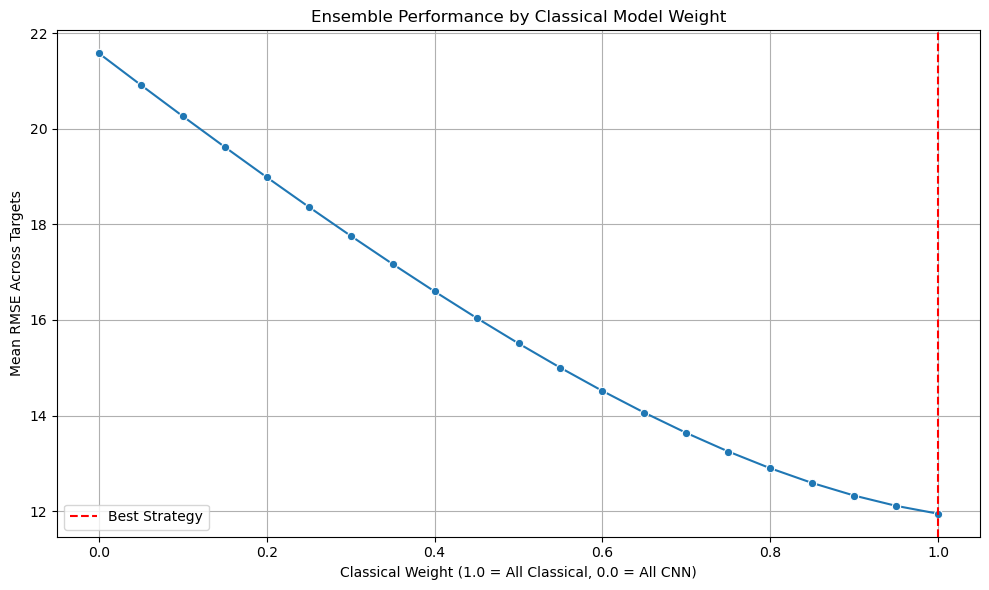

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=ensemble_df, x='weight_classical', y='mean_rmse', marker='o')
plt.title('Ensemble Performance by Classical Model Weight')
plt.xlabel('Classical Weight (1.0 = All Classical, 0.0 = All CNN)')
plt.ylabel('Mean RMSE Across Targets')
plt.grid(True)
plt.axvline(x=ensemble_df.loc[ensemble_df["mean_rmse"].idxmin()]["weight_classical"], color='r', linestyle='--', label='Best Strategy')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_ensemble_weight_search.png")
plt.show()

## 5. Final Strategy Selection

We pinpoint the exact classical and CNN weight distribution that minimizes the mean RMSE.

In [15]:
best_strategy = ensemble_df.loc[ensemble_df["mean_rmse"].idxmin()]
best_w_class = float(best_strategy["weight_classical"])
best_w_cnn = float(best_strategy["weight_cnn"])

logging.info(f"Selected Strategy - Classical Weight: {best_w_class:.2f}, CNN Weight: {best_w_cnn:.2f}")

2026-07-09 15:44:41,147 - INFO - Selected Strategy - Classical Weight: 1.00, CNN Weight: 0.00


We save this final strategy configuration. This artifact dictates the inference pipeline behavior.

In [16]:
strategy_config = {
    "weight_classical": best_w_class,
    "weight_cnn": best_w_cnn,
    "expected_mean_rmse": float(best_strategy["mean_rmse"])
}
with open(REPORTS_DIR / "08_final_strategy.json", "w") as f:
    json.dump(strategy_config, f, indent=4)

# Calculate and save best ensemble metrics
best_oof_preds = (best_w_class * pred_06) + (best_w_cnn * pred_07)
best_ensemble_metrics = evaluate_predictions(y_true, best_oof_preds, "Weighted Ensemble")
best_ensemble_metrics.to_csv(REPORTS_DIR / "08_best_ensemble_per_target_metrics.csv", index=False)

# Best Strategy Actual vs Predicted & Residuals Figures
fig, axes = plt.subplots(1, len(TARGET_COLUMNS), figsize=(20, 4))
for i, t in enumerate(TARGET_COLUMNS):
    axes[i].scatter(y_true[:, i], best_oof_preds[:, i], alpha=0.5)
    axes[i].plot([y_true[:, i].min(), y_true[:, i].max()], [y_true[:, i].min(), y_true[:, i].max()], 'r--')
    axes[i].set_title(t)
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_best_strategy_actual_vs_predicted.png")
plt.close()

fig, axes = plt.subplots(1, len(TARGET_COLUMNS), figsize=(20, 4))
for i, t in enumerate(TARGET_COLUMNS):
    residuals = y_true[:, i] - best_oof_preds[:, i]
    axes[i].scatter(best_oof_preds[:, i], residuals, alpha=0.5)
    axes[i].axhline(0, color='r', linestyle='--')
    axes[i].set_title(f"{t} Residuals")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_best_strategy_residuals.png")
plt.close()

## 6. Test Data Preparation

We load the raw test metadata (`test.csv`) and the competition sample submission template.

In [17]:
test_df = pd.read_csv(TEST_CSV)
unique_images = test_df["image_path"].unique()
test_images_df = pd.DataFrame({"image_path": unique_images})

We verify the raw test image paths and resolve them to absolute file paths for our custom `src/` modules.

In [18]:
def get_absolute_path(rel_path):
    return str(DATA_DIR / "raw" / rel_path)

test_images_df["absolute_path"] = test_images_df["image_path"].apply(get_absolute_path)
logging.info(f"Total unique test images: {len(test_images_df)}")

2026-07-09 15:44:42,036 - INFO - Total unique test images: 1


## 7. Test Inference Pipeline

### 7.1. Advanced Classical Inference

If the optimal strategy utilizes the Classical model (weight > 0.0), we first load the best configuration identified in Notebook 06.

In [19]:
if best_w_class > 0.0:
    with open(REPORTS_DIR / "06_best_configuration.json", "r") as f:
        best_cfg = json.load(f)
    feature_set_name = best_cfg["feature_set"]
    model_type = "extra_trees"
    logging.info(f"Using classical feature set: {feature_set_name}")

2026-07-09 15:44:42,044 - INFO - Using classical feature set: All_Features


We extract CNN embeddings and handcrafted visual features for the test set using the verified source functions.

In [21]:
if best_w_class > 0.0:
    test_cnn_dataset = build_image_dataset(
        test_images_df["absolute_path"].tolist(),
        batch_size=32,
    )

    feature_extractor = build_efficientnet_feature_extractor()

    test_cnn_features = extract_cnn_features(
        model=feature_extractor,
        dataset=test_cnn_dataset,
    )

    cnn_cols = [
        f"cnn_{i:04d}"
        for i in range(test_cnn_features.shape[1])
    ]

    test_visual_features = extract_visual_features_batch(
        test_images_df["absolute_path"].tolist()
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Finished processing 1/1 images.


We construct a dummy metadata table for the test set. All test items lack metadata, so the `SimpleImputer` within our preprocessor will substitute learned median/mode values.

In [22]:
if best_w_class > 0.0:
    test_metadata_raw = pd.DataFrame(np.nan, index=test_images_df.index, columns=METADATA_COLUMNS)
    train_features_df = pd.read_csv(TRAIN_FEATURES_CSV)
    feature_groups = identify_advanced_feature_columns(train_features_df)
    canonical_columns = feature_groups[feature_set_name.lower()]
    fold_classical_preds = []

We iterate through all saved 5-fold cross-validation pipelines. For each fold, we transform the features using the *fold-specific* preprocessor, combine them in canonical order, and generate test predictions.

In [24]:
model_path = (
    MODELS_CLASSICAL_DIR
    / f"06_best_{best_cfg['model'].lower()}_{feature_set_name.lower()}_fold_0.joblib"
)

loaded_object = joblib.load(model_path)

print("Path:", model_path)
print("Type:", type(loaded_object))
print("Value:", loaded_object)

Path: E:\DATAVIDWAN\Image2Biomass\models\advanced\extra_trees\06_best_extratrees_all_features_fold_0.joblib
Type: <class 'int'>
Value: 0


In [25]:
if best_w_class > 0.0:
    for fold in range(5):
        # 1. Transform Metadata
        preprocessor_path = DATA_DIR / "processed" / "cached_features" / "metadata_preprocessors" / f"metadata_preprocessor_fold_{fold}.joblib"
        preprocessor = joblib.load(preprocessor_path)
        test_metadata_fold = preprocessor.transform(test_metadata_raw)
        meta_cols = preprocessor.get_feature_names_out().tolist()
        
        # 2. Combine Features
        fold_features_df = pd.DataFrame(index=test_images_df.index)
        fold_features_df = pd.concat([fold_features_df, pd.DataFrame(test_cnn_features, columns=cnn_cols, index=test_images_df.index)], axis=1)
        fold_features_df = pd.concat([fold_features_df, pd.DataFrame(test_metadata_fold, columns=meta_cols, index=test_images_df.index)], axis=1)
        fold_features_df = pd.concat([fold_features_df, pd.DataFrame(test_visual_features.values, columns=test_visual_features.columns, index=test_images_df.index)], axis=1)
        
        # 3. Predict
        X_test = fold_features_df[canonical_columns].to_numpy(dtype=np.float32)
        model = joblib.load(MODELS_CLASSICAL_DIR / f"06_best_{best_cfg['model'].lower()}_{feature_set_name.lower()}_fold_{fold}.joblib")
        preds = np.clip(model.predict(X_test), a_min=0.0, a_max=None)
        fold_classical_preds.append(preds)
        
    classical_test_predictions = np.mean(fold_classical_preds, axis=0)
else:
    classical_test_predictions = np.zeros((len(test_images_df), len(TARGET_COLUMNS)))

### 7.2. End-to-End CNN Inference

If the optimal strategy utilizes the CNN model (weight > 0.0), we instantiate the test dataset and generate predictions using the 5 saved Keras fold models.

In [26]:
if best_w_cnn > 0.0:
    logging.info("Running CNN Inference...")
    test_dataset = build_image_dataset(test_images_df["absolute_path"].tolist(), batch_size=32)
    fold_cnn_preds = []
    
    for fold in range(5):
        model = tf.keras.models.load_model(MODELS_CNN_DIR / f"fold{fold}.keras")
        preds = np.clip(model.predict(test_dataset), a_min=0.0, a_max=None)
        fold_cnn_preds.append(preds)
        
    cnn_test_predictions = np.mean(fold_cnn_preds, axis=0)
else:
    cnn_test_predictions = np.zeros((len(test_images_df), len(TARGET_COLUMNS)))

## 8. Final Artifact Generation & Validation

We calculate the final weighted predictions across the test set.

In [27]:
final_predictions = (best_w_class * classical_test_predictions) + (best_w_cnn * cnn_test_predictions)
pred_df = pd.DataFrame(final_predictions, columns=TARGET_COLUMNS)
pred_df["image_path"] = test_images_df["image_path"]

We save the inference validation test predictions alongside the best strategy OOF predictions.

In [28]:
test_preds_path = OOF_DIR / "08_test_predictions.csv"
pred_df.to_csv(test_preds_path, index=False)
logging.info(f"Test predictions saved to {test_preds_path}")

oof_pred_df = pd.DataFrame(best_oof_preds, columns=[f"{t}_pred" for t in TARGET_COLUMNS])
oof_pred_df["image_path"] = oof_07["image_path"]
for i, t in enumerate(TARGET_COLUMNS):
    oof_pred_df[f"actual_{t}"] = y_true[:, i]

oof_preds_path = OOF_DIR / "08_best_strategy_oof_predictions.csv"
oof_pred_df.to_csv(oof_preds_path, index=False)
logging.info(f"Best strategy OOF predictions saved to {oof_preds_path}")

# Integrity validation
integrity_records = [
    {"Artifact": "Test Predictions", "Exists": test_preds_path.exists(), "Size": len(pred_df)},
    {"Artifact": "OOF Predictions", "Exists": oof_preds_path.exists(), "Size": len(oof_pred_df)},
    {"Artifact": "Strategy Config", "Exists": (REPORTS_DIR / "08_final_strategy.json").exists(), "Size": 1}
]
integrity_df = pd.DataFrame(integrity_records)
integrity_report_path = REPORTS_DIR / "08_final_integrity_report.csv"
integrity_df.to_csv(integrity_report_path, index=False)
logging.info(f"Final integrity report saved to {integrity_report_path}")
display(integrity_df)

2026-07-09 17:24:29,739 - INFO - Test predictions saved to E:\DATAVIDWAN\Image2Biomass\outputs\predictions\08_test_predictions.csv
2026-07-09 17:24:29,745 - INFO - Best strategy OOF predictions saved to E:\DATAVIDWAN\Image2Biomass\outputs\predictions\08_best_strategy_oof_predictions.csv
2026-07-09 17:24:29,748 - INFO - Final integrity report saved to E:\DATAVIDWAN\Image2Biomass\outputs\reports\08_final_integrity_report.csv


,Artifact,Exists,Size
0,Test Predictions,True,1
1,OOF Predictions,True,357
2,Strategy Config,True,1


In [29]:
from src.inference import validate_inference_artifacts

validation = validate_inference_artifacts()
validation

2026-07-09 17:48:27,965 - INFO - Loaded 1389 canonical feature columns.
2026-07-09 17:48:28,905 - INFO - Loaded and validated 5 fold models.
2026-07-09 17:48:28,911 - INFO - Loaded and validated 5 metadata preprocessors.
2026-07-09 17:48:28,912 - INFO - Inference artifacts validated successfully.


{'strategy': {'weight_classical': 1.0,
  'weight_cnn': 0.0,
  'expected_mean_rmse': 11.948850329422298},
 'configuration': {'model': 'ExtraTrees',
  'feature_set': 'All_Features',
  'number_of_features': 1389,
  'mean_MAE': 8.094050931930543,
  'mean_RMSE': 11.841108152437872,
  'mean_R2': 0.6303136110305786,
  'n_folds': 5,
  'targets': ['Dry_Clover_g',
   'Dry_Dead_g',
   'Dry_Green_g',
   'Dry_Total_g',
   'GDM_g']},
 'n_canonical_features': 1389,
 'n_models': 5,
 'n_preprocessors': 5}

In [30]:
print("=" * 60)
print("INFERENCE MODULE CONSISTENCY TEST")
print("=" * 60)

from src.inference import predict_batch

# Run reusable inference module on the same test samples
module_test_predictions = predict_batch(
    image_paths=test_images_df["absolute_path"].tolist(),
    metadata=test_metadata_raw,
)

print(f"Module prediction shape : {module_test_predictions.shape}")
print(f"Expected prediction shape: {classical_test_predictions.shape}")

# Notebook 08 predictions as DataFrame
notebook_test_predictions = pd.DataFrame(
    classical_test_predictions,
    columns=TARGET_COLUMNS,
)

# Compare predictions
prediction_difference = np.abs(
    module_test_predictions[TARGET_COLUMNS].to_numpy()
    - notebook_test_predictions[TARGET_COLUMNS].to_numpy()
)

max_absolute_difference = prediction_difference.max()
mean_absolute_difference = prediction_difference.mean()

print()
print(f"Maximum absolute difference: {max_absolute_difference:.10f}")
print(f"Mean absolute difference   : {mean_absolute_difference:.10f}")

# Validation
assert module_test_predictions.shape == notebook_test_predictions.shape

assert np.allclose(
    module_test_predictions[TARGET_COLUMNS].to_numpy(),
    notebook_test_predictions[TARGET_COLUMNS].to_numpy(),
    rtol=1e-5,
    atol=1e-6,
), (
    "inference.py predictions do not match "
    "Notebook 08 predictions."
)

assert not module_test_predictions.isna().any().any()

assert not np.isinf(
    module_test_predictions.to_numpy()
).any()

assert (
    module_test_predictions.to_numpy() >= 0
).all()

print()
print("=" * 60)
print("INFERENCE MODULE CONSISTENCY VALIDATION PASSED")
print("=" * 60)

display(module_test_predictions)

2026-07-09 17:49:31,529 - INFO - Loaded 1389 canonical feature columns.


INFERENCE MODULE CONSISTENCY TEST


2026-07-09 17:49:32,056 - INFO - Loaded and validated 5 fold models.
2026-07-09 17:49:32,062 - INFO - Loaded and validated 5 metadata preprocessors.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


2026-07-09 17:49:34,736 - INFO - Extracted CNN features with shape (1, 1280).
2026-07-09 17:49:34,958 - INFO - Extracted visual features with shape (1, 89).
2026-07-09 17:49:35,081 - INFO - Completed inference for fold 0.


Finished processing 1/1 images.


2026-07-09 17:49:35,221 - INFO - Completed inference for fold 1.
2026-07-09 17:49:35,356 - INFO - Completed inference for fold 2.
2026-07-09 17:49:35,498 - INFO - Completed inference for fold 3.
2026-07-09 17:49:35,631 - INFO - Completed inference for fold 4.
2026-07-09 17:49:35,633 - INFO - Completed batch inference for 1 samples.


Module prediction shape : (1, 5)
Expected prediction shape: (1, 5)

Maximum absolute difference: 0.0000007487
Mean absolute difference   : 0.0000003414

INFERENCE MODULE CONSISTENCY VALIDATION PASSED


,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,3.669263,20.111622,14.736727,38.514896,18.405991


In [32]:
from src.config import RAW_DATA_DIR

test_df = pd.read_csv(RAW_DATA_DIR / "test.csv")

print(test_df.iloc[0])

sample_id      ID1001187975__Dry_Clover_g
image_path          test/ID1001187975.jpg
target_name                  Dry_Clover_g
Name: 0, dtype: object


In [37]:
from src.config import (
    PROJECT_ROOT,
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    PREDICTIONS_DIR
)

print("PROJECT_ROOT       :", PROJECT_ROOT)
print("DATA_DIR           :", DATA_DIR)
print("RAW_DATA_DIR       :", RAW_DATA_DIR)
print("PROCESSED_DATA_DIR :", PROCESSED_DATA_DIR)
print("MODELS_DIR         :", MODELS_DIR)
print("OUTPUTS_DIR        :", OUTPUTS_DIR)

print()
print("PROJECT_ROOT exists       :", PROJECT_ROOT.exists())
print("DATA_DIR exists           :", DATA_DIR.exists())
print("RAW_DATA_DIR exists       :", RAW_DATA_DIR.exists())
print("PROCESSED_DATA_DIR exists :", PROCESSED_DATA_DIR.exists())
print("MODELS_DIR exists         :", MODELS_DIR.exists())
print("OUTPUTS_DIR exists        :", OUTPUTS_DIR.exists())

print()
print("test.csv exists:", (RAW_DATA_DIR / "test.csv").exists())

PROJECT_ROOT       : E:\DATAVIDWAN\Image2Biomass
DATA_DIR           : E:\DATAVIDWAN\Image2Biomass\data
RAW_DATA_DIR       : E:\DATAVIDWAN\Image2Biomass\data\raw
PROCESSED_DATA_DIR : E:\DATAVIDWAN\Image2Biomass\data\processed
MODELS_DIR         : E:\DATAVIDWAN\Image2Biomass\models
OUTPUTS_DIR        : E:\DATAVIDWAN\Image2Biomass\outputs

PROJECT_ROOT exists       : True
DATA_DIR exists           : True
RAW_DATA_DIR exists       : True
PROCESSED_DATA_DIR exists : True
MODELS_DIR exists         : True
OUTPUTS_DIR exists        : True

test.csv exists: True


In [39]:
from src.config import RAW_DATA_DIR
import pandas as pd

train_df = pd.read_csv(RAW_DATA_DIR / "train.csv")

# One row per image
sample = train_df.drop_duplicates("image_path").iloc[0]

print("IMAGE")
print(RAW_DATA_DIR / sample["image_path"])

print("\nMETADATA")
for column in [
    "State",
    "Species",
    "Pre_GSHH_NDVI",
    "Height_Ave_cm",
]:
    print(f"{column}: {sample[column]}")

IMAGE
E:\DATAVIDWAN\Image2Biomass\data\raw\train\ID1011485656.jpg

METADATA
State: Tas
Species: Ryegrass_Clover
Pre_GSHH_NDVI: 0.62
Height_Ave_cm: 4.6667


In [40]:
from src.metadata_features import METADATA_COLUMNS
print(METADATA_COLUMNS)

['State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']


In [41]:
from src.inference import predict_single_sample

test_prediction = predict_single_sample(
    image_path=r"E:\DATAVIDWAN\Image2Biomass\data\raw\train\ID1011485656.jpg",
    metadata={
        "State": "Tas",
        "Species": "Ryegrass_Clover",
        "Pre_GSHH_NDVI": 0.62,
        "Height_Ave_cm": 4.6667,
    },
)

test_prediction

2026-07-09 18:15:46,319 - INFO - Loaded 1389 canonical feature columns.
2026-07-09 18:15:46,872 - INFO - Loaded and validated 5 fold models.
2026-07-09 18:15:46,878 - INFO - Loaded and validated 5 metadata preprocessors.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


2026-07-09 18:15:49,035 - INFO - Extracted CNN features with shape (1, 1280).
2026-07-09 18:15:49,167 - INFO - Extracted visual features with shape (1, 89).


Finished processing 1/1 images.


2026-07-09 18:15:49,241 - INFO - Completed inference for fold 0.
2026-07-09 18:15:49,313 - INFO - Completed inference for fold 1.
2026-07-09 18:15:49,383 - INFO - Completed inference for fold 2.
2026-07-09 18:15:49,454 - INFO - Completed inference for fold 3.
2026-07-09 18:15:49,551 - INFO - Completed inference for fold 4.
2026-07-09 18:15:49,552 - INFO - Completed batch inference for 1 samples.


{'Dry_Clover_g': 4.847642421722412,
 'Dry_Dead_g': 20.70248794555664,
 'Dry_Green_g': 17.24860191345215,
 'Dry_Total_g': 42.79712677001953,
 'GDM_g': 22.09623908996582}

In [45]:
import pandas as pd
from src.config import RAW_DATA_DIR

train_df = pd.read_csv(RAW_DATA_DIR / "train.csv")

sample_path = "train/ID1011485656.jpg"

actual = (
    train_df[train_df["image_path"] == sample_path]
    .set_index("target_name")["target"]
)

comparison = pd.DataFrame({
    "Actual": actual,
    "Predicted": pd.Series(test_prediction),
})

comparison["Absolute_Error"] = (
    comparison["Actual"] - comparison["Predicted"]
).abs()

comparison["Percentage_Error"] = (
    comparison["Absolute_Error"]
    / comparison["Actual"].replace(0, float("nan"))
    * 100
)

display(comparison)

,Actual,Predicted,Absolute_Error,Percentage_Error
Dry_Clover_g,0.0000,4.847642,4.847642,NaN
Dry_Dead_g,31.9984,20.702488,11.295912,35.301490
Dry_Green_g,16.2751,17.248602,0.973502,5.981542
Dry_Total_g,48.2735,42.797127,5.476373,11.344471
GDM_g,16.2750,22.096239,5.821239,35.767982
